In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

sns.set_style('darkgrid')
np.set_printoptions(precision=2)
warnings.filterwarnings("ignore")

import sklearn
from sklearn.preprocessing import MinMaxScaler, StandardScaler, Normalizer, Binarizer, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, LabelEncoder, PowerTransformer
from sklearn.impute import SimpleImputer, KNNImputer

from sklearn.feature_selection import SelectKBest, chi2, RFE
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline, Pipeline
from sklearn.decomposition import PCA

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, f1_score

from sklearn.model_selection import KFold, ShuffleSplit, LeaveOneOut, StratifiedKFold
from sklearn.model_selection import cross_val_score, cross_val_predict
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV
""" Semilla """
seed = 99


In [2]:

#df = pd.read_csv("c:/Users/dagom/Documents/docencia/DOCENCIA_FINAL_2023_PHYTON_ML_DANI/2_Introduccion_y_SVM/SAheart.csv", sep=",", decimal=".")
data=pd.read_csv('SAheartbis.csv')


y=pd.DataFrame(data["chd"])
X=data.drop(columns="chd")


[X_train, X_test, y_train, y_test] = train_test_split(X, y, test_size = 0.30, random_state = 101)



In [3]:

### numero de baggings  4
#s1= muestreo con reemplazamiento
import random
n= len(X_train)
s_size=0.45 # tamaño de cada muestra del bagging
n = s_size*n # tamaño de la muestra del bagging
# X_train # lista de datos de la cual queremos hacer la muestra
random.seed(2020)
s1 = random.choices(range(len(X_train)), k=int(n))
X_train_s1 = X_train.iloc[s1]
y_train_s1 = y_train.iloc[s1]
s2 = random.choices(range(len(X_train)), k=int(n))
X_train_s2 = X_train.iloc[s2]
y_train_s2 = y_train.iloc[s2]
s3 = random.choices(range(len(X_train)), k=int(n))
X_train_s3 = X_train.iloc[s3]
y_train_s3 = y_train.iloc[s3]
s4 = random.choices(range(len(X_train)), k=int(n))
X_train_s4 = X_train.iloc[s4]
y_train_s4 = y_train.iloc[s4]

In [5]:


## modelo de ML sobre el que queremos hacer el bagging
## Paso 1 sin bagging
prediciones = [] ## aqui voy a meter todas las predicciones de los modelos 1+ 4
prediciones_t = [] ## aqui voy a meter todas las predicciones de los modelos 4  en train

model=LogisticRegression(random_state=seed)
model.fit(X_train,y_train)
prediction=model.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
prediction=pd.DataFrame(prediction, columns=['LR'])
prediciones.append(prediction)

accuracy=model.score(X_test, y_test)
print('Accuracy Test en modelo original' ,accuracy)
print(classification_report(y_test, model.predict(X_test)))


# Paso 2 hacemos el entrenamiento y prediccion  de los 4 muestras en test y train
model.fit(X_train_s1,y_train_s1)
prediction=model.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
prediction=pd.DataFrame(prediction, columns=['LR_s1'])
prediciones.append(prediction)



model.fit(X_train_s2,y_train_s2)
prediction=model.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
prediction=pd.DataFrame(prediction, columns=['LR_s2'])
prediciones.append(prediction)


model.fit(X_train_s3,y_train_s3)
prediction=model.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
prediction=pd.DataFrame(prediction, columns=['LR_s3'])
prediciones.append(prediction)



model.fit(X_train_s4,y_train_s4)
prediction=model.predict_proba(X_test)[:,1] ## me quedo con la probabilidad del si
prediction=pd.DataFrame(prediction, columns=['LR_s4'])
prediciones.append(prediction)



display(prediciones[0])
display(prediciones[1])
display(prediciones[2])
display(prediciones[3])
display(prediciones[4])




Accuracy Test en modelo original 0.697841726618705
              precision    recall  f1-score   support

          No       0.71      0.87      0.78        86
          Si       0.67      0.42      0.51        53

    accuracy                           0.70       139
   macro avg       0.69      0.64      0.65       139
weighted avg       0.69      0.70      0.68       139



,LR
0,0.507178
1,0.055655
2,0.081393
3,0.313353
4,0.755245
...,...
134,0.186609
135,0.045239
136,0.093396
137,0.400247


,LR_s1
0,0.631545
1,0.070913
2,0.039296
3,0.430643
4,0.923830
...,...
134,0.142095
135,0.017038
136,0.025027
137,0.214491


,LR_s2
0,0.695219
1,0.053780
2,0.094465
3,0.195126
4,0.807059
...,...
134,0.313340
135,0.049900
136,0.158127
137,0.810475


,LR_s3
0,0.388255
1,0.110714
2,0.264787
3,0.709269
4,0.384144
...,...
134,0.464521
135,0.081081
136,0.119203
137,0.804679


,LR_s4
0,0.614579
1,0.061586
2,0.039716
3,0.069421
4,0.902881
...,...
134,0.175236
135,0.046109
136,0.033113
137,0.155510


In [6]:


### ahora viene el momento de agregar las 4 predicciones

prediccion_bagging= pd.DataFrame((prediciones[1]["LR_s1"] +  prediciones[2]["LR_s2"]
                                  + prediciones[3]["LR_s3"] + prediciones[4]["LR_s4"] )/4)


#pred2= max(prediciones[1]["LR_s1"], prediciones[2]["LR_s2"], prediciones[3]["LR_s3"], prediciones[4]["LR_s4"])
display(prediccion_bagging)

display(prediciones[0])


,0
0,0.582399
1,0.074248
2,0.109566
3,0.351115
4,0.754478
...,...
134,0.273798
135,0.048532
136,0.083867
137,0.496289


,LR
0,0.507178
1,0.055655
2,0.081393
3,0.313353
4,0.755245
...,...
134,0.186609
135,0.045239
136,0.093396
137,0.400247


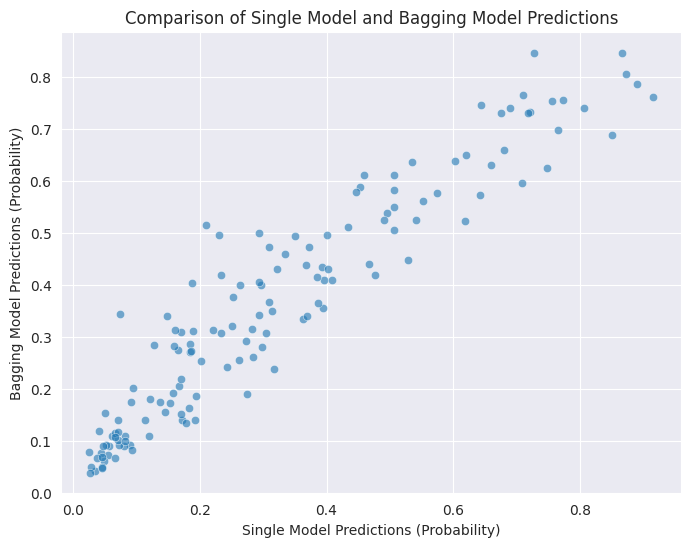

In [7]:

# Combine the predictions into a single DataFrame
predictions_comparison = pd.DataFrame({
    'Single Model Predictions': prediciones[0]['LR'],
    'Bagging Model Predictions': prediccion_bagging.iloc[:, 0] # Select the first column by index
})

# Create a scatter plot
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Single Model Predictions', y='Bagging Model Predictions', data=predictions_comparison, alpha=0.6)
plt.title('Comparison of Single Model and Bagging Model Predictions')
plt.xlabel('Single Model Predictions (Probability)')
plt.ylabel('Bagging Model Predictions (Probability)')
plt.grid(True)
plt.show()

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Ensure y_test is in a suitable format (e.g., a Pandas Series)
if isinstance(y_test, pd.DataFrame):
    y_test_series = y_test.iloc[:, 0]
else:
    y_test_series = y_test

# Combine the predictions and y_test into a single DataFrame
predictions_comparison = pd.DataFrame({
    'Single Model Predictions': prediciones[0]['LR'],
    'Bagging Model Predictions': prediccion_bagging.iloc[:, 0],
    'True Class': y_test_series
})

# Create a scatter plot, coloring by the 'True Class'
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Single Model Predictions', y='Bagging Model Predictions', hue='True Class', data=predictions_comparison, alpha=0.6, palette={0: 'blue', 1: 'red'})

# Add horizontal and vertical lines at 0.5
plt.axhline(0.5, color='gray', linestyle='--', linewidth=1)
plt.axvline(0.5, color='gray', linestyle='--', linewidth=1)

plt.title('Comparison of Single Model and Bagging Model Predictions by True Class')
plt.xlabel('Single Model Predictions (Probability)')
plt.ylabel('Bagging Model Predictions (Probability)')
plt.grid(True)
plt.show()

ValueError: The palette dictionary is missing keys: {'No', 'Si'}

<Figure size 800x600 with 0 Axes>

COMPARAMOS AMBOS MODELOS !!!!


In [ ]:

from sklearn.preprocessing import Binarizer

transformer= Binarizer(threshold=0.5).fit(prediccion_bagging)  # fit does nothing.
prediccion_bagging_binaria=pd.DataFrame(transformer.transform(prediccion_bagging))
y_test.replace(('Si', 'No'), (1, 0), inplace=True)
cm = confusion_matrix(y_test, prediccion_bagging_binaria)
accuracy_bagging=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])

print("Accuracy Bagging: ", accuracy_bagging)
print(cm)

Accuracy Bagging:  0.7338129496402878
[[74 12]
 [25 28]]


TRAIN / TEST

In [ ]:
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import Binarizer
import pandas as pd

single_model_train_predictions = model.predict_proba(X_train)[:, 1]
single_model_train_predictions = pd.Series(single_model_train_predictions, name='LR_Train')


In [9]:


######################### bagging general con blucle !!!!!

import random
from sklearn.linear_model import LogisticRegression
import pandas as pd

# Supongamos que ya has dividido tus datos en conjuntos de entrenamiento y prueba
# X_train, X_test, y_train, y_test

# Numero de baggings
num_baggings = 100
s_size = 0.45  # Tamaño de cada muestra del bagging

# Inicializar listas para almacenar las predicciones de cada bagging
predicciones_baggings = []

for i in range(num_baggings):
    # Generar muestra aleatoria con reemplazo
    random.seed(2020 + i)  # Cambiando la semilla para cada iteración
    n = s_size * len(X_train)
    s = random.choices(range(len(X_train)), k=int(n))
    X_train_s = X_train.iloc[s]
    y_train_s = y_train.iloc[s]

    # Inicializar y ajustar el modelo de regresión logística
    model = LogisticRegression(random_state=1)
    model.fit(X_train_s, y_train_s)

    # Realizar predicciones en el conjunto de prueba
    prediction = model.predict_proba(X_test)[:, 1]
    prediction = pd.DataFrame(prediction, columns=[f'LR_s{i + 1}'])  # Cambiar el nombre de la columna para cada bagging
    predicciones_baggings.append(prediction)

# Calcular la predicción del bagging promediando todas las predicciones
prediccion_bagging = pd.DataFrame(sum(pred[f'LR_s{i + 1}'] for i, pred in enumerate(predicciones_baggings)) / num_baggings, columns=['Bagging'])

from sklearn.preprocessing import Binarizer

transformer= Binarizer(threshold=0.5).fit(prediccion_bagging)  # fit does nothing.
prediccion_bagging_binaria=pd.DataFrame(transformer.transform(prediccion_bagging))
y_test.replace(('Si', 'No'), (1, 0), inplace=True)
cm = confusion_matrix(y_test, prediccion_bagging_binaria)
accuracy_bagging=(cm[0,0]+cm[1,1])/(cm[0,1]+cm[1,1]+ cm[1,0]+cm[0,0])

print("Accuracy Bagging: ", accuracy_bagging)
print(cm)






Accuracy Bagging:  0.7194244604316546
[[77  9]
 [30 23]]


In [ ]:
import numpy as np
import pandas as pd
from sklearn.svm import SVC
from sklearn.ensemble import BaggingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

def bagging_svm_performance(X, y, sample_sizes, n_estimators_values):
    """
    Evaluates the performance of a BaggingClassifier with a linear kernel SVM as the base estimator.

    Args:
        X: The feature matrix.
        y: The target variable.
        sample_sizes: A list of sample sizes for the bagging classifier.
        n_estimators_values: A list of the number of estimators for the bagging classifier.
    """
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.30, random_state = 101)
    results = []

    for sample_size in sample_sizes:
        for n_estimators in n_estimators_values:
            train_accuracies = []
            test_accuracies = []
            bagging_clf = BaggingClassifier(
                    estimator=SVC(kernel='linear', C=0.19),
                    n_estimators=n_estimators,
                    max_samples=sample_size,
                    max_features=1.0,
                    random_state=42  # Keep random state consistent for comparison
                )

            bagging_clf.fit(X_train, y_train)
            y_train_pred = bagging_clf.predict(X_train)
            y_test_pred = bagging_clf.predict(X_test)
            train_accuracy = accuracy_score(y_train, y_train_pred)
            test_accuracy = accuracy_score(y_test, y_test_pred)

            train_accuracies.append(train_accuracy)
            test_accuracies.append(test_accuracy)

            accuracy_diff = train_accuracy - test_accuracy

            results.append({
                'sample_size': sample_size,
                'n_estimators': n_estimators,
                'train_accuracy': train_accuracy,
                'test_accuracy': test_accuracy,
                'accuracy_diff': accuracy_diff
            })

    return pd.DataFrame(results)


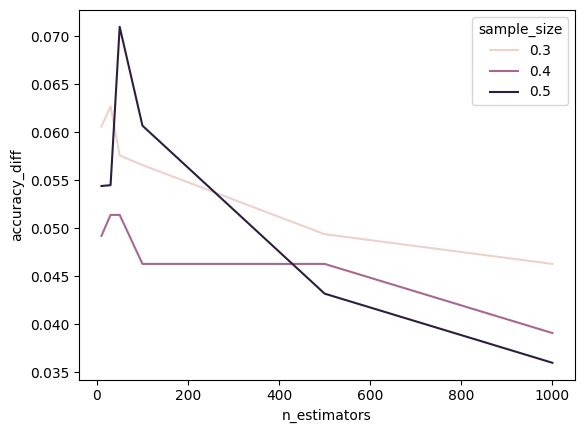

In [ ]:
# Example usage (replace with your actual data):
from sklearn.datasets import make_classification

data=pd.read_csv('SAheartbis.csv')

data = data.drop(columns=["Unnamed: 0"]) ## depende de la versión la exporta

y=pd.DataFrame(data["chd"])
# Convierte y en un array 1D
y = y.values.ravel()
X=data.drop(columns="chd")



sample_sizes = [0.3, 0.4, 0.5]
n_estimators_values = [10, 30, 50, 100, 500, 1000]


results_df = bagging_svm_performance(X, y, sample_sizes, n_estimators_values)
results_df



import seaborn as sns
sns.lineplot(x='n_estimators', y='accuracy_diff', hue='sample_size', data=results_df)
plt.show()

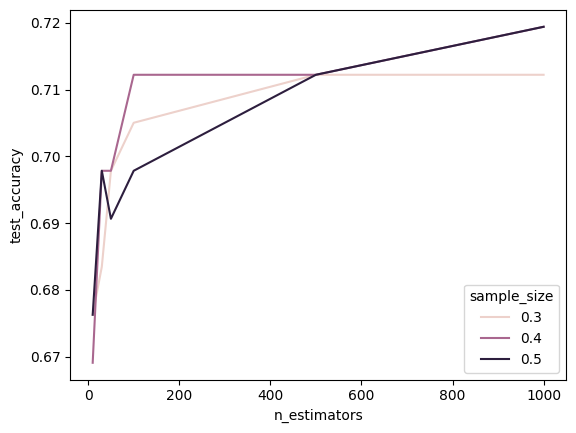

In [ ]:

import seaborn as sns
sns.lineplot(x='n_estimators', y='test_accuracy', hue='sample_size', data=results_df)
plt.show()

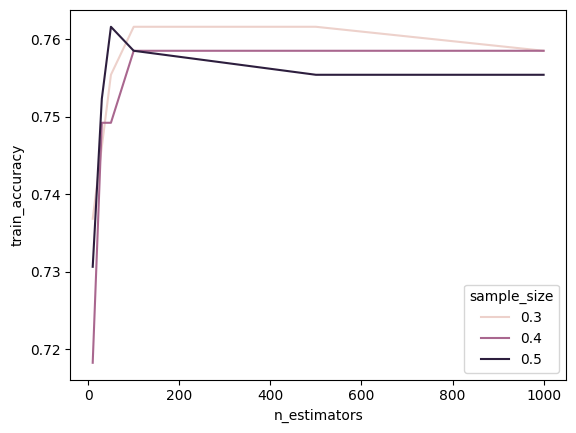

In [ ]:

import seaborn as sns
sns.lineplot(x='n_estimators', y='train_accuracy', hue='sample_size', data=results_df)
plt.show()

In [ ]:

# Example usage (replace with your actual data):
from sklearn.datasets import make_classification
X, y = make_classification(n_samples=1000, n_features=20, n_informative=10, random_state=42)


sample_sizes = [0.5, 0.7, 0.9, 1.0]
n_estimators_values = [10, 20, 30, 50]


results_df = bagging_svm_performance(X, y, sample_sizes, n_estimators_values)
results_df


# Plotting (optional, uncomment to visualize)
#import seaborn as sns
#sns.lineplot(x='n_estimators', y='accuracy_diff', hue='sample_size', data=results_df)
#plt.show()